# TEST corpus: proton elastic

The Test corpus comprises directly-measured elastic scattering, analyzing power and integral cross section data that post-date the KD and CH89 publications, drawn entirely from EXFOR.

Proton differential elastic scattering cross sections, stored as a ratio to Rutherford against CM scattering angle. EXFOR reports some of these data sets as ratios and others as absolute cross sections; the absolute ones are divided by the Rutherford cross section so the sector is uniform.

The subentries and scattering energies below are transcribed from the supplement's
tables into `spec/test_proton_elastic.csv`. Every row must be accounted for: it either
produces data, or it is listed in `spec/known_missing.csv` with a reason. Uncertainties
are assigned by the supplement's preference rule (`nn_corpora.errors`), and the
corrections its Comments describe are applied from `nn_corpora.overrides`.

In [1]:
%matplotlib inline
import matplotlib
from matplotlib import pyplot as plt

import pandas as pd

from nn_corpora import corpus, plotting, report, spec

pd.set_option("display.max_rows", 200)

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31


## The specification

In [2]:
rows = spec.load_sector('test', 'proton_elastic')
print(f"{len(rows)} rows, {len({r.subentry for r in rows if r.in_exfor})} distinct subentries")
pd.DataFrame([vars(r) for r in rows]).head(15)

12 rows, 12 distinct subentries


,corpus,sector,projectile,target_A,target_Z,target_label,energy_mev,energy_hi_mev,subentry,pointer,pdf_page
0,test,proton_elastic,proton,24,12,24Mg,7.4,None,F1277002,,31
1,test,proton_elastic,proton,58,28,58Ni,172.0,None,D0350003,,31
2,test,proton_elastic,proton,58,28,58Ni,250.0,None,E2042003,,31
3,test,proton_elastic,proton,64,30,64Zn,24.0,None,O2165003,,31
4,test,proton_elastic,proton,116,50,116Sn,295.0,None,E2098002,,31
5,test,proton_elastic,proton,118,50,118Sn,295.0,None,E2098003,,31
6,test,proton_elastic,proton,120,50,120Sn,200.0,None,E2042007,,31
7,test,proton_elastic,proton,120,50,120Sn,250.0,None,E2042010,,31
8,test,proton_elastic,proton,120,50,120Sn,295.0,None,E2098004,,31
9,test,proton_elastic,proton,120,50,120Sn,300.0,None,E2042012,,31


## Retrieve and clean

`corpus.curate` retrieves each entry, matches measurements back to the rows that asked
for them, applies the documented corrections, and homogenises units and frames.

In [3]:
result = corpus.curate('test', 'proton_elastic')
print(result.summary())

test/proton_elastic
  spec rows              12
  ... marked absent      0
  ... resolved           11 / 12 (91.7%)
  measurements           11
  data points            314
  EXFOR entries          4
  unresolved by category
    x4i3-parse-failure       1
  serialized             11 measurements, 314 points


## Rows that did not resolve

Every row listed here must appear in `spec/known_missing.csv`, or the write below will
fail. The categories are: `absent-from-exfor` (the supplement itself marks the row as
not locatable), `x4i3-parse-failure` (the entry is in EXFOR but x4i3 cannot read it),
`subentry-withdrawn` (EXFOR has renumbered or removed the subentry since the supplement
was written), `energy-not-found`, and `uncertainty-unresolved`.

In [4]:
print(report.unresolved_table(result.data))

64Zn    24.000 O2165003  [x4i3-parse-failure] parse failed: Error while parsing O2165003: Expected only one DATA column, found 0


## Uncertainty audit

Data sets with missing uncertainties are dropped during munging, following the
supplement's removal of any data set lacking a necessary feature. This lists anything
that survived but still looks suspicious.

In [5]:
flags = plotting.check_uncertainties(result)
print("\n".join(flags) if flags else "every measurement carries uncertainties")

every measurement carries uncertainties


## Inspect

Outliers here are found by eye. A mistranscribed point shows up as a single datum an
order of magnitude away from its neighbours; a badly normalised data set shows up as a
whole curve offset from others at the same energy.

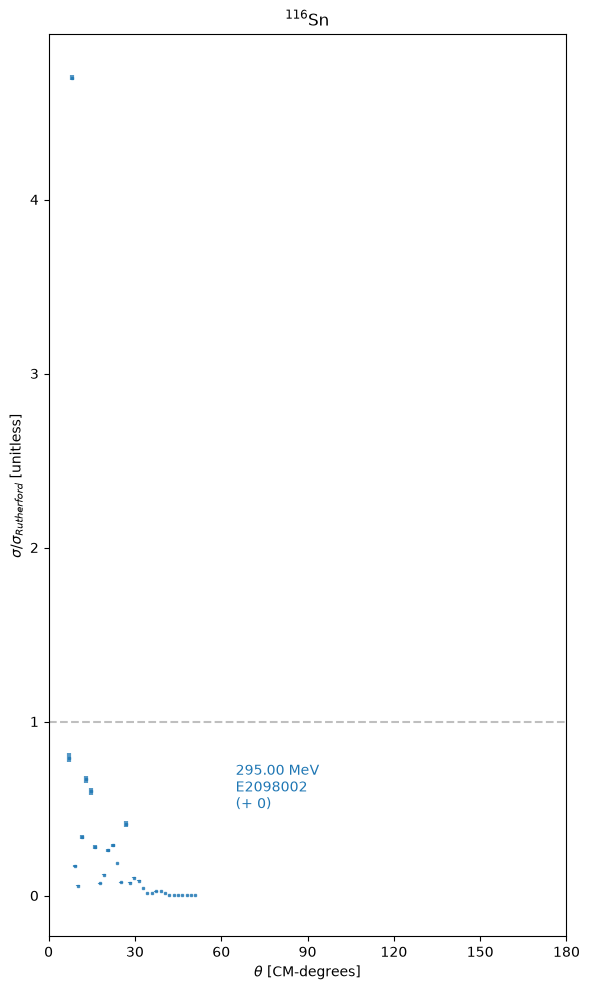

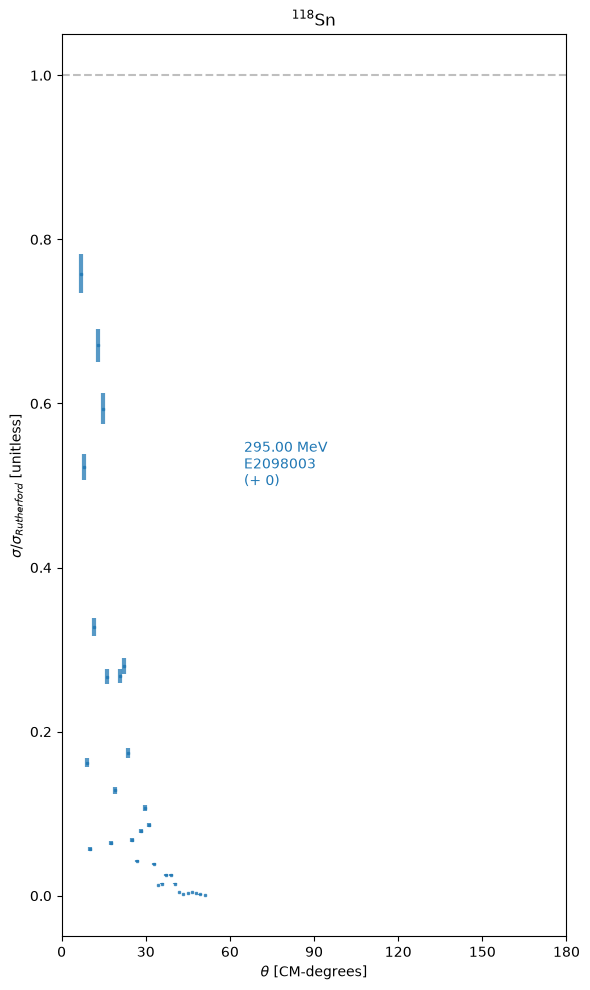

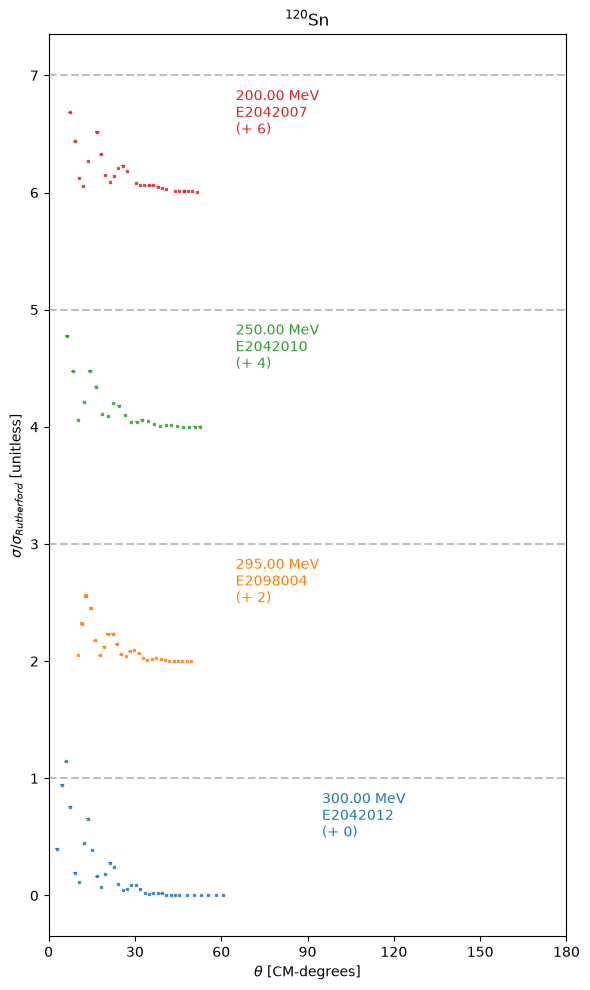

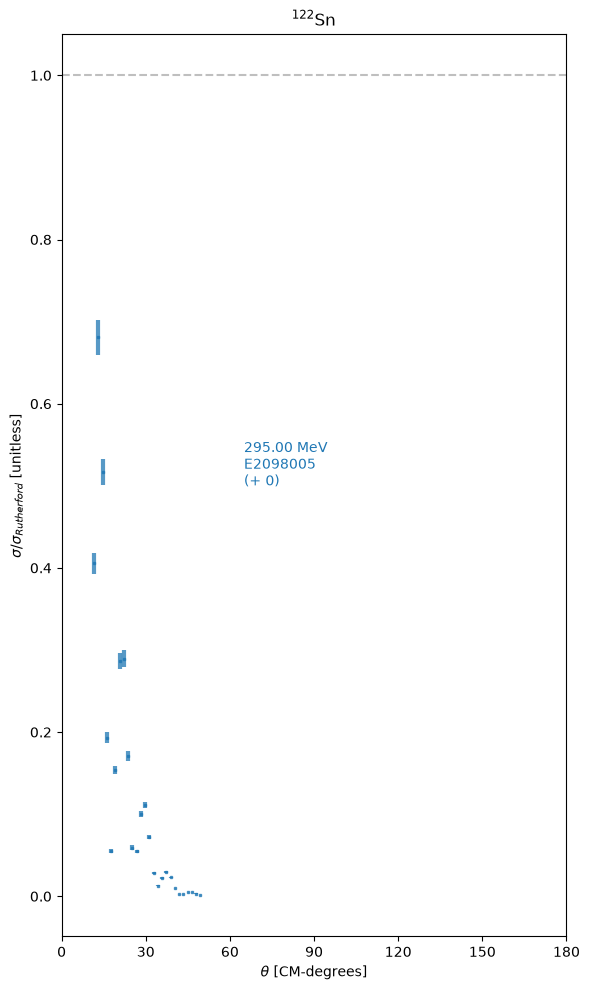

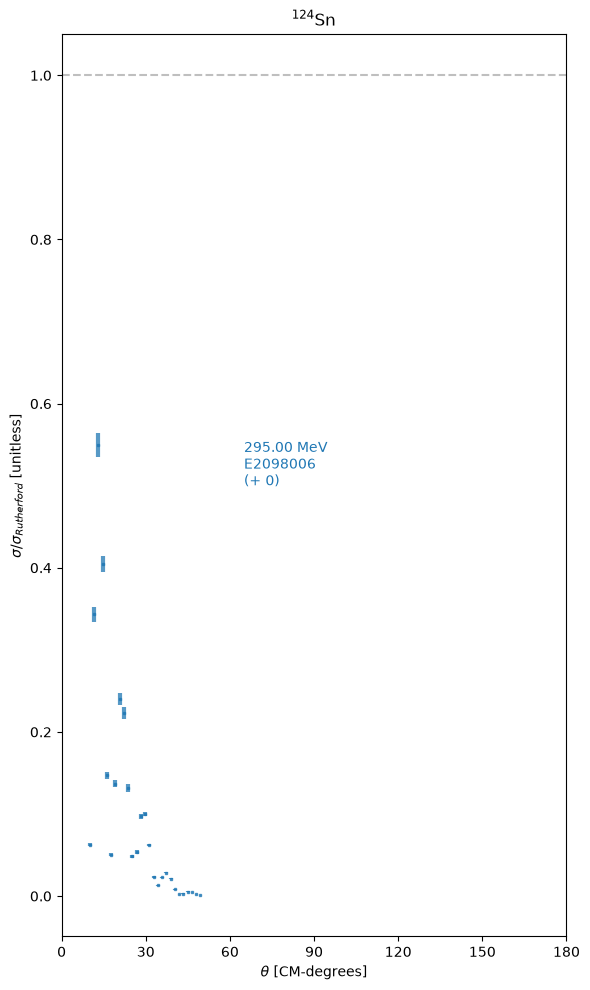

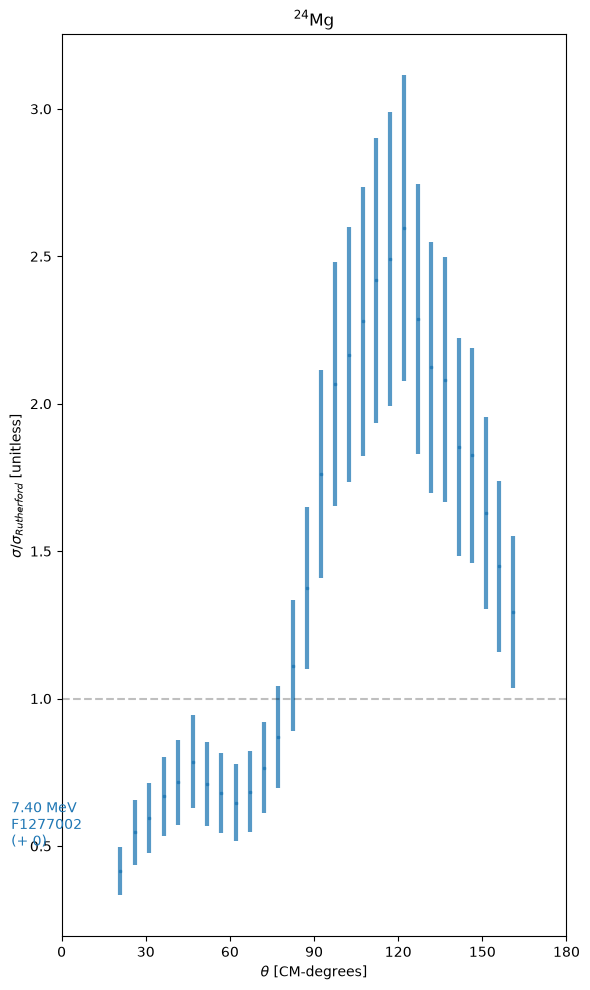

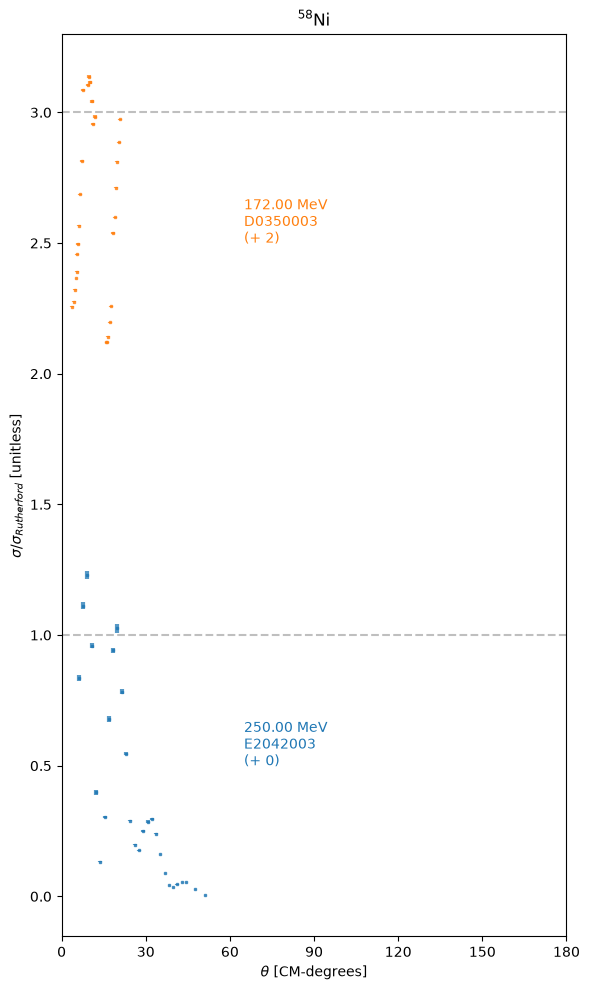

In [6]:
plotting.plot_sector(result, max_targets=8)
plt.show()

## Write

`corpus.write` re-checks coverage against the allowlist before writing, so a data set
that silently disappears from EXFOR fails here rather than passing unnoticed.

In [7]:
corpus.write(result)
print(f"wrote {len(result.records)} measurements to data/{result.corpus}/{result.sector}/")

wrote 11 measurements to data/test/proton_elastic/
